# Carregamento do DataSet

In [55]:
%reload_ext autoreload
%autoreload 2

from variables import filenames, features, target
from load_dataset import load
from pre_processing import apply, ReplaceInfWithNan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
df = load(filenames)
df = apply(df)
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


# Preprocessamento

# Analise do Dataset

In [57]:
df.drop(columns=["Destination Port"], inplace=True)
df.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,109,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,52,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,34,1,1,6,6,6,6,6.0,0.0,6,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,3,2,0,12,0,6,6,6.0,0.0,0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [58]:
df = df[df['Label'].isin(['BENIGN','DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye'])]
df['Label'].value_counts()

Label
BENIGN              2096484
DoS Hulk             172849
DoS GoldenEye         10286
DoS slowloris          5385
DoS Slowhttptest       5228
Name: count, dtype: int64

In [59]:
# Muda os ataques para categorias mais genéricas, para facilitar a visualização e o entendimento dos dados
print("Unique labels before mapping:", df['Label'].unique())
attack_mapping = {
    'BENIGN': 'Benign',
    'DDoS': 'DDoS',
    'DoS slowloris': 'DoS - Slowloris',
    'DoS Slowhttptest': 'DoS - Slowhttptest',
    'DoS Hulk': 'DoS - Hulk',
    'DoS GoldenEye': 'DoS - GoldenEye'
}

df['Label'] = df['Label'].map(attack_mapping)
print("\n\nUnique labels after mapping:", df['Label'].unique())

Unique labels before mapping: ['BENIGN' 'DoS slowloris' 'DoS Slowhttptest' 'DoS Hulk' 'DoS GoldenEye']


Unique labels after mapping: ['Benign' 'DoS - Slowloris' 'DoS - Slowhttptest' 'DoS - Hulk'
 'DoS - GoldenEye']


In [60]:
df['Label'].value_counts()

Label
Benign                2096484
DoS - Hulk             172849
DoS - GoldenEye         10286
DoS - Slowloris          5385
DoS - Slowhttptest       5228
Name: count, dtype: int64

In [61]:
# Variância de todas as colunas numéricas
cols = df.columns.drop("Label", errors="ignore")
variancias = df[cols].select_dtypes(include=np.number).var().sort_values()

# Lista das colunas com variância 0 (ou muito próxima de 0)
colunas_variancia_zero = variancias[np.isclose(variancias, 0.0)].index.tolist()

print("\nColunas com variância igual a 0 (ou muito próxima de 0):")
print(colunas_variancia_zero)

# Remove essas colunas do DataFrame
df = df.drop(columns=colunas_variancia_zero, errors="ignore")
print(f"\nTotal de colunas removidas: {len(colunas_variancia_zero)}")

/home/alfredolsn/Documents/Suricata_ML/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)



Colunas com variância igual a 0 (ou muito próxima de 0):
['Fwd Avg Packets/Bulk', 'Bwd URG Flags', 'Bwd PSH Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

Total de colunas removidas: 8


In [62]:
col1, col2 = "Fwd Header Length", "Fwd Header Length.1"

if col1 not in df.columns or col2 not in df.columns:
    print(f"Coluna ausente. Disponíveis? {col1 in df.columns=}, {col2 in df.columns=}")
else:
    iguais = df[col1].equals(df[col2])  # compara considerando NaN na mesma posição como igual
    print(f"As colunas '{col1}' e '{col2}' são totalmente iguais? {iguais}")

    mask_diff = ~(df[col1].eq(df[col2]) | (df[col1].isna() & df[col2].isna()))
    qtd_diff = int(mask_diff.sum())
    total = len(df)

    print(f"Total de linhas: {total}")
    print(f"Linhas diferentes: {qtd_diff} ({(qtd_diff/total)*100:.6f}%)")

    if qtd_diff > 0:
        print("\nExemplos de diferenças:")
        display(df.loc[mask_diff, [col1, col2]].head(10))

As colunas 'Fwd Header Length' e 'Fwd Header Length.1' são totalmente iguais? True
Total de linhas: 2290232
Linhas diferentes: 0 (0.000000%)


In [63]:
#Remover a coluna "Fwd Header Length.1" por ser idêntica à "Fwd Header Length"
if "Fwd Header Length.1" in df.columns:
    df.drop(columns=["Fwd Header Length.1"], inplace=True)
    print("Coluna 'Fwd Header Length.1' removida por ser idêntica a 'Fwd Header Length'.")

Coluna 'Fwd Header Length.1' removida por ser idêntica a 'Fwd Header Length'.


## Remover colunas com baixa importancia <= 0.005

In [64]:
columns_low_importance = ['RST Flag Count', 'ECE Flag Count', 'Fwd URG Flags', 'CWE Flag Count', 'SYN Flag Count', 'Bwd Packet Length Min', 'Fwd PSH Flags', 'Min Packet Length', 'URG Flag Count', 'Down/Up Ratio', 'ACK Flag Count', 'Idle Std', 'Active Std', 'PSH Flag Count', 'Fwd Packet Length Min', 'Bwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Max', 'Idle Mean', 'min_seg_size_forward', 'Active Mean', 'Avg Fwd Segment Size', 'act_data_pkt_fwd', 'Active Max', 'Bwd IAT Std', 'Active Min', 'Bwd IAT Mean', 'Fwd Packet Length Std', 'Flow IAT Min', 'Fwd Packet Length Mean', 'Fwd IAT Min', 'Bwd Header Length']
df = df.drop(columns=columns_low_importance)

In [65]:
df.shape

(2290232, 37)

In [66]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df["Class"] = label_encoder.fit_transform(df["Label"].astype(str))

mapa_classes = pd.DataFrame({
    "Label": label_encoder.classes_,
    "Class": range(len(label_encoder.classes_))
})

display(mapa_classes)

,Label,Class
0,Benign,0
1,DoS - GoldenEye,1
2,DoS - Hulk,2
3,DoS - Slowhttptest,3
4,DoS - Slowloris,4


In [67]:
df.drop(columns=["Label"], inplace=True)

## Separação Treino/Teste


In [68]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.20, random_state=42, stratify=df['Class'])

## Balanceamento

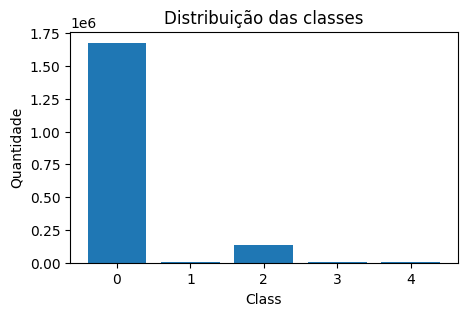

In [71]:
def plot_class_distribution(df, class_col="Class"):
    counts = df[class_col].value_counts().sort_index()
    plt.figure(figsize=(5,3))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title("Distribuição das classes")
    plt.xlabel("Class")
    plt.ylabel("Quantidade")
    plt.show()
plot_class_distribution(df_train)

In [72]:
df_train['Class'].value_counts()

Class
0    1677187
2     138279
1       8229
4       4308
3       4182
Name: count, dtype: int64

In [73]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(
    sampling_strategy={
        0: min(100000, df_train["Class"].value_counts()[0]),  # Benign
        2: min(100000, df_train["Class"].value_counts()[2]),  # DoS Hulk
        1: df_train["Class"].value_counts()[1],               # DoS GoldenEye
        3: df_train["Class"].value_counts()[3],               # DoS Slowhttptest
        4: df_train["Class"].value_counts()[4],               # DoS Slowloris
    },
    random_state=42
)

df_train_bal, _ = rus.fit_resample(
    df_train,
    df_train["Class"]
)

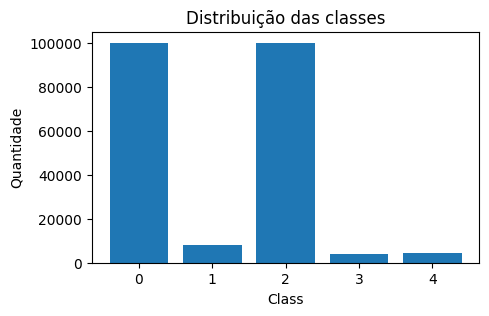

In [75]:
plot_class_distribution(df_train_bal)

In [76]:
df_train_bal['Class'].value_counts()

Class
0    100000
2    100000
1      8229
4      4308
3      4182
Name: count, dtype: int64

# Treinamento

In [80]:
X_train = df_train_bal.drop(columns=["Class"])
y_train = df_train_bal["Class"]

X_test = df_test.drop(columns=["Class"])
y_test = df_test["Class"]

In [81]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from pre_processing import ReplaceInfWithNan

model = Pipeline(steps=[
    ("replace_inf", ReplaceInfWithNan()),
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(random_state=42, n_estimators=100, warm_start=True))
])

In [82]:
from tqdm import tqdm
import time

start = time.time()
model.fit(X_train, y_train)
end = time.time()
print(f"Treinamento concluído em {end - start:.2f} segundos")

Treinamento concluído em 45.34 segundos


## Salvamento do Modelo e Scaler

In [83]:
import joblib
import os 

#Cria a pasta modelo caso não exista
os.makedirs("modelo", exist_ok=True)

# Salvar o modelo treinado
joblib.dump(model, "./modelo/pipeline.joblib")

# Salvar o LabelEncoder
joblib.dump(label_encoder, "modelo/label_encoder.joblib")

# Salvar o scaler
#joblib.dump(scaler, "modelo/minmax_scaler.joblib")

['modelo/label_encoder.joblib']

## Avaliação do Modelo

In [84]:
y_predict = model.predict(X_test)

In [85]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

def show_classification_metrics(y_true, y_pred):
    print("Acurácia:", accuracy_score(y_true, y_pred))
    print("Precisão:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))
    print("\nRelatório de Classificação:")
    print(classification_report(y_true, y_pred))

    # Matriz de confusão gráfica
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predito')
    plt.ylabel('Real')
    plt.title('Matriz de Confusão')
    plt.show()

def plot_roc_auc(y_true, y_pred_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    auc = roc_auc_score(y_true, y_pred_proba)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('FPR (False Positive Rate)')
    plt.ylabel('TPR (True Positive Rate)')
    plt.title('Curva ROC')
    plt.legend(loc='lower right')
    plt.show()
    print(f'AUC: {auc:.4f}')

Acurácia: 0.9984914211860355
Precisão: 0.9985245682794649
Recall: 0.9984914211860355
F1 Score: 0.9985002137505471

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419297
           1       0.96      1.00      0.98      2057
           2       0.99      1.00      0.99     34570
           3       0.92      0.99      0.95      1046
           4       0.98      1.00      0.99      1077

    accuracy                           1.00    458047
   macro avg       0.97      1.00      0.98    458047
weighted avg       1.00      1.00      1.00    458047



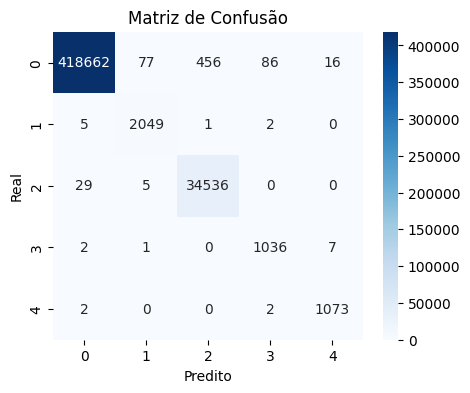

In [87]:
show_classification_metrics(y_test, y_predict)

In [88]:
rf = model.named_steps['classifier']

In [89]:
import pandas as pd

importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

importances.head(20)

,feature,importance
8,Bwd Packet Length Std,0.122453
27,Avg Bwd Segment Size,0.088406
7,Bwd Packet Length Mean,0.077646
24,Packet Length Variance,0.060904
6,Bwd Packet Length Max,0.056326
23,Packet Length Std,0.053515
26,Average Packet Size,0.050130
31,Subflow Bwd Bytes,0.045475
22,Packet Length Mean,0.041818
21,Max Packet Length,0.034924


In [74]:
importances.to_csv("feature_importances.csv", index=False)

In [75]:
IMPORTANCE_THRESHOLD = 0.005

low_importance = importances[
    importances["importance"] < IMPORTANCE_THRESHOLD
].copy()

low_importance = low_importance.sort_values("importance")

features_to_remove_by_importance = low_importance["feature"].tolist()

print(f"Features com importance < {IMPORTANCE_THRESHOLD}:")
print(features_to_remove_by_importance)

print(f"\nTotal de features candidatas à remoção: {len(features_to_remove_by_importance)}")

Features com importance < 0.005:
['RST Flag Count', 'ECE Flag Count', 'Fwd URG Flags', 'CWE Flag Count', 'SYN Flag Count', 'Bwd Packet Length Min', 'Fwd PSH Flags', 'Min Packet Length', 'URG Flag Count', 'Down/Up Ratio', 'ACK Flag Count', 'Idle Std', 'Active Std', 'PSH Flag Count', 'Fwd Packet Length Min', 'Bwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Max', 'Idle Mean', 'min_seg_size_forward', 'Active Mean', 'Avg Fwd Segment Size', 'act_data_pkt_fwd', 'Active Max', 'Bwd IAT Std', 'Active Min', 'Bwd IAT Mean', 'Fwd Packet Length Std', 'Flow IAT Min', 'Fwd Packet Length Mean', 'Fwd IAT Min', 'Bwd Header Length']

Total de features candidatas à remoção: 32
